# Imports

# Functions

## Confusion Matircies - Means and Standard Deviations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import confusion_matrix
import os
from glob import glob

def create_percentage_confusion_matrix_mean_std_EI_MSMS(
    folder, 
    folder_name, 
    bin_size, 
    threshold_size, 
    use_super_test=False, 
    save_plots=True, 
    test_in=True,
    train_in=False, 
    num_loops=None
):
    """
    Compute mean and stddev of percentage confusion matrices for EI_MSMS data.
    This version includes synthetic data in training.
    """

    if not test_in and not train_in:
        print("No data to use, toggle train_in or test_in to True.")
        return

    def response_to_tox_class_local(response_value):
        if response_value <= 5:
            return 0
        elif response_value <= 50:
            return 1
        elif response_value <= 500:
            return 2
        elif response_value <= 5000:
            return 3
        else:
            return 4

    # Prepare the file pattern for glob
    folder_path = os.path.join(folder, folder_name)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    
    # Match the actual filename format from training script
    base_fp = (
        f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra"
        if use_super_test else f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra"
    )
    file_pattern = os.path.join(folder_path, f"{base_fp}_loop*.parquet")

    file_list = sorted(glob(file_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching pattern: {file_pattern}")
    if num_loops is not None:
        file_list = file_list[:num_loops]

    all_cm_percent = []
    n_classes = 5
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]

    for fname in file_list:
        df = pd.read_parquet(fname)
        # Filter based on train_in and test_in flags
        if 'train' in df.columns:
            if train_in and test_in:
                # Include both train and test
                pass
            elif train_in:
                # Include only train
                df = df[df['train'] == 1].copy()
            elif test_in:
                # Include only test
                df = df[df['train'] == 0].copy()
        
        df['tox_class'] = df['Response'].apply(response_to_tox_class_local)

        y_true = df['tox_class'].values
        y_pred = df['cond_tox_pred_class'].values

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
        # Row-wise normalization (%)
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            cm_percent = np.nan_to_num(cm_percent)
        all_cm_percent.append(cm_percent)

    all_cm_percent = np.array(all_cm_percent)  # shape (n_files, n_classes, n_classes)
    mean_cm = np.mean(all_cm_percent, axis=0)
    std_cm = np.std(all_cm_percent, axis=0)

    # Plotting
    plt.figure(figsize=(10, 8))
    annot = np.empty_like(mean_cm, dtype=object)
    for i in range(n_classes):
        for j in range(n_classes):
            annot[i, j] = f"{mean_cm[i, j]:.1f}±{std_cm[i, j]:.1f}"

    sns.heatmap(
        mean_cm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        cbar_kws={'label': 'Mean Percentage (%)'},
        square=True
    )

    test_type = "Super Test" if use_super_test else "Validation"
    # Build data label based on train_in and test_in
    if train_in and test_in:
        data_label = " (Train + Test)"
    elif train_in:
        data_label = " (Train Only)"
    elif test_in:
        data_label = " (Test Only)"
    else:
        data_label = ""
    
    plt.title(f"EI_MSMS Confusion Matrix (Mean±Std%) - {test_type}{data_label}\n(Bin={bin_size}, Threshold={threshold_size})\nn={len(file_list)} loops")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    if save_plots:
        save_path = os.path.join(folder_path, f"EI_MSMS_confusion_matrix_percentages_meanstd_{'super_test_' if use_super_test else ''}bin{bin_size}_thr{threshold_size}_loops.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")

    plt.show()
    # No return statement - function only displays the plot

# Plotly Plot

In [2]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_chemnet_pca_plotly_with_sliders_EI_MSMS(
    bin_val=1, 
    threshold_val=0.05, 
    loop_num=0,
    use_synth_abl=False,  # NEW: Toggle between full model and synthetic ablation
    include_super_test=True, 
    include_regular_test=True, 
    include_true_chemnet=True, 
    include_training=True,
    color_by_smiles=True, 
    super_test_black=False,
    data_type_coloring=False,
    random_seed=42,
    max_smiles_values=[5, 10, 15, 20, 30, 40, 50],
    max_spectra_values=[1, 3, 5, 7, 10, 15, 20]
):
    """
    Create interactive Plotly figure with sliders for EI_MSMS data.
    Pre-computes plots for different max_smiles and max_spectra combinations.
    
    Parameters:
    -----------
    bin_val : float
        Binary threshold value (e.g., 1)
    threshold_val : float
        Threshold value (e.g., 0.05)
    loop_num : int
        Loop number (e.g., 0, 1, 2)
    use_synth_abl : bool
        If True, use synthetic ablation folders; if False, use full model folders
    include_super_test : bool
        Include super test data
    include_regular_test : bool
        Include regular test data (train=0)
    include_training : bool
        Include training data (train=1)
    include_true_chemnet : bool
        Include true ChemNet embeddings from merged_EI_MSMS_chemnet.parquet
    color_by_smiles : bool
        Color points by SMILES (True) or all black (False)
    super_test_black : bool
        Color super test data in black instead of by SMILES
    data_type_coloring : bool
        If True, train=red, test=blue (overrides SMILES coloring for train/test)
    random_seed : int
        Random seed for reproducibility
    max_smiles_values : list
        List of max_smiles values to pre-compute
    max_spectra_values : list
        List of max_spectra values to pre-compute
    """
    base_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data"
    
    # Choose folders based on synthetic ablation flag
    if use_synth_abl:
        loop_folder = f"{base_folder}/2step_EI_MSMS_synth_abl_Loop"
        super_loop_folder = f"{base_folder}/2step_EI_MSMS_synth_abl_loop_super_test"
        model_type = "Synth-Abl"
    else:
        loop_folder = f"{base_folder}/2_step_EI_MSMS_Loop"
        super_loop_folder = f"{base_folder}/2_step_EI_MSMS_loop_super_test"
        model_type = "Full"
    
    # Format bin and threshold with underscores
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    
    # Construct file paths
    regular_file = f"{loop_folder}/cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra_loop{loop_num}.parquet"
    super_file = f"{super_loop_folder}/super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra_loop{loop_num}.parquet"
    chemnet_file = f"{base_folder}/merged_EI_MSMS_chemnet.parquet"

    # Helper functions
    def pad_or_truncate(embeddings, target_dim):
        if embeddings.shape[1] < target_dim:
            return np.hstack([embeddings, np.zeros((embeddings.shape[0], target_dim - embeddings.shape[1]))])
        elif embeddings.shape[1] > target_dim:
            return embeddings[:, :target_dim]
        return embeddings

    def get_true_tox_class(row):
        """Extract true toxicity class from dummy variables."""
        for i in range(5):
            col = f'tox_level_{i}'
            if col in row.index and row[col] == 1:
                return i
        return None

    def sample_spectra_per_chemical(df, smiles_col, max_per_smiles, seed):
        selected_rows = []
        for smile in df[smiles_col].unique():
            smile_rows = df[df[smiles_col] == smile]
            if len(smile_rows) > max_per_smiles:
                selected_rows.extend(smile_rows.sample(max_per_smiles, random_state=seed).index)
            else:
                selected_rows.extend(smile_rows.index)
        return df.loc[selected_rows]

    def load_all_super_test_data(file_path, smiles_col, max_spectra, seed):
        try:
            df = pd.read_parquet(file_path)
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra, seed)
            if not embedding_cols or len(df) == 0:
                return None, None, None, None, None
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            true_classes = df.apply(get_true_tox_class, axis=1).values
            pred_classes = df['cond_tox_pred_class'].values if 'cond_tox_pred_class' in df.columns else [None] * len(df)
            
            return embeddings, smiles, true_classes, pred_classes, embedding_cols
        except Exception as e:
            print(f"Error loading super test data: {e}")
            return None, None, None, None, None

    def load_and_sample_regular_data(file_path, filter_train, max_smiles, max_spectra, smiles_col, 
                                    required_smiles=None, seed=None):
        try:
            df = pd.read_parquet(file_path)
            if 'train' in df.columns:
                df = df[df['train'] == filter_train]
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            if not embedding_cols or len(df) == 0:
                return None, None, None, None, set()
            if required_smiles is not None and len(required_smiles) > 0:
                df = df[df[smiles_col].isin(required_smiles)]
            else:
                unique_smiles = pd.unique(df[smiles_col])
                if len(unique_smiles) > max_smiles:
                    if seed is not None:
                        np.random.seed(seed)
                    selected_smiles_subset = np.random.choice(unique_smiles, max_smiles, replace=False)
                    df = df[df[smiles_col].isin(selected_smiles_subset)]
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra, seed)
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            true_classes = df.apply(get_true_tox_class, axis=1).values
            pred_classes = df['cond_tox_pred_class'].values if 'cond_tox_pred_class' in df.columns else [None] * len(df)
            
            return embeddings, smiles, true_classes, pred_classes, set(smiles)
        except Exception as e:
            print(f"Error loading regular data: {e}")
            return None, None, None, None, set()

    def load_chemnet_data(file_path, selected_smiles, max_spectra, smiles_col, seed, smiles_to_class_map):
        """Load ChemNet data and map SMILES to true toxicity classes."""
        try:
            df = pd.read_parquet(file_path)
            # For EI_MSMS, embedding columns are like 'Embedding Float 0', 'Embedding Float 1', etc.
            embedding_cols = [col for col in df.columns if col.startswith('Embedding Float ')]
            embedding_cols.sort(key=lambda x: int(x.split()[-1]))
            df = df[df[smiles_col].isin(selected_smiles)]
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra, seed)
            if not embedding_cols or len(df) == 0:
                return None, None, None, None
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            
            # Map SMILES to true classes using the provided map
            true_classes = [smiles_to_class_map.get(smile, None) for smile in smiles]
            pred_classes = [None] * len(df)  # ChemNet doesn't have predictions
            
            return embeddings, smiles, true_classes, pred_classes
        except Exception as e:
            print(f"Error loading ChemNet data: {e}")
            return None, None, None, None

    def generate_pca_plot(max_smiles_per_set, max_spectra_per_chemical):
        """Generate PCA plot with given parameters."""
        smiles_col = "SMILES_spectra"
        
        # Load super test data
        super_test_embeddings = None
        super_test_smiles = None
        super_test_true_classes = None
        super_test_pred_classes = None
        super_test_smiles_set = set()
        
        if include_super_test:
            super_test_embeddings, super_test_smiles, super_test_true_classes, super_test_pred_classes, _ = \
                load_all_super_test_data(super_file, smiles_col, max_spectra_per_chemical, random_seed)
            if super_test_embeddings is not None:
                super_test_smiles_set = set(super_test_smiles)

        # Fit PCA on super test data if available
        embedding_dim = None
        scaler = None
        pca = None
        if super_test_embeddings is not None:
            embedding_dim = super_test_embeddings.shape[1]
            scaler = StandardScaler()
            super_test_scaled = scaler.fit_transform(super_test_embeddings)
            pca = PCA(n_components=2, random_state=42)
            pca.fit(super_test_scaled)

        # Collect all data
        all_embeddings = []
        all_smiles = []
        all_true_classes = []
        all_pred_classes = []
        all_dataset_types = []
        selected_smiles_all = set()
        regular_test_smiles_set = set()
        
        # Create SMILES to true class mapping from loaded data
        smiles_to_class_map = {}

        # Load regular test data
        if include_regular_test:
            reg_test_emb, reg_test_smiles, reg_test_true, reg_test_pred, regular_test_smiles_set = \
                load_and_sample_regular_data(regular_file, 0, max_smiles_per_set, max_spectra_per_chemical, 
                                            smiles_col, seed=random_seed)
            if reg_test_emb is not None:
                if embedding_dim is None:
                    embedding_dim = reg_test_emb.shape[1]
                else:
                    reg_test_emb = pad_or_truncate(reg_test_emb, embedding_dim)
                all_embeddings.extend(reg_test_emb)
                all_smiles.extend(reg_test_smiles)
                all_true_classes.extend(reg_test_true)
                all_pred_classes.extend(reg_test_pred)
                all_dataset_types.extend(["Regular Test"] * len(reg_test_smiles))
                selected_smiles_all.update(reg_test_smiles)
                
                # Build SMILES to class map
                for smile, true_class in zip(reg_test_smiles, reg_test_true):
                    if true_class is not None:
                        smiles_to_class_map[smile] = true_class

        # Load training data
        if include_training:
            train_emb, train_smiles, train_true, train_pred, _ = \
                load_and_sample_regular_data(regular_file, 1, max_smiles_per_set, max_spectra_per_chemical,
                                            smiles_col, required_smiles=regular_test_smiles_set if include_regular_test else None, 
                                            seed=random_seed)
            if train_emb is not None:
                if embedding_dim is None:
                    embedding_dim = train_emb.shape[1]
                else:
                    train_emb = pad_or_truncate(train_emb, embedding_dim)
                all_embeddings.extend(train_emb)
                all_smiles.extend(train_smiles)
                all_true_classes.extend(train_true)
                all_pred_classes.extend(train_pred)
                all_dataset_types.extend(["Training"] * len(train_smiles))
                selected_smiles_all.update(train_smiles)
                
                # Build SMILES to class map
                for smile, true_class in zip(train_smiles, train_true):
                    if true_class is not None:
                        smiles_to_class_map[smile] = true_class

        # Add super test data
        if include_super_test and super_test_embeddings is not None:
            all_embeddings.extend(super_test_embeddings)
            all_smiles.extend(super_test_smiles)
            all_true_classes.extend(super_test_true_classes)
            all_pred_classes.extend(super_test_pred_classes)
            all_dataset_types.extend(["Super Test"] * len(super_test_smiles))
            selected_smiles_all.update(super_test_smiles)
            
            # Build SMILES to class map
            for smile, true_class in zip(super_test_smiles, super_test_true_classes):
                if true_class is not None:
                    smiles_to_class_map[smile] = true_class

        # Load true ChemNet embeddings with mapped classes
        if include_true_chemnet:
            chemnet_emb, chemnet_smiles, chemnet_true, chemnet_pred = \
                load_chemnet_data(chemnet_file, selected_smiles_all, max_spectra_per_chemical, smiles_col, random_seed, smiles_to_class_map)
            if chemnet_emb is not None:
                if embedding_dim is None:
                    embedding_dim = chemnet_emb.shape[1]
                else:
                    chemnet_emb = pad_or_truncate(chemnet_emb, embedding_dim)
                all_embeddings.extend(chemnet_emb)
                all_smiles.extend(chemnet_smiles)
                all_true_classes.extend(chemnet_true)
                all_pred_classes.extend(chemnet_pred)
                all_dataset_types.extend(["True ChemNet"] * len(chemnet_smiles))

        if not all_embeddings:
            return None

        # Convert to arrays
        embeddings_matrix = np.array(all_embeddings)
        smiles_array = np.array(all_smiles)
        true_classes_array = np.array(all_true_classes)
        pred_classes_array = np.array(all_pred_classes)
        dataset_types_array = np.array(all_dataset_types)

        # Apply PCA
        if scaler is not None and pca is not None:
            embeddings_scaled = scaler.transform(embeddings_matrix)
            embeddings_2d = pca.transform(embeddings_scaled)
        else:
            scaler = StandardScaler()
            embeddings_scaled = scaler.fit_transform(embeddings_matrix)
            pca = PCA(n_components=2, random_state=42)
            embeddings_2d = pca.fit_transform(embeddings_scaled)

        # Color scheme
        point_colors = []
        
        if data_type_coloring:
            for i, dtype in enumerate(dataset_types_array):
                if dtype == "Training":
                    point_colors.append('red')
                elif dtype == "Regular Test":
                    point_colors.append('blue')
                else:
                    point_colors.append('black')
        elif color_by_smiles:
            unique_smiles = list(set(smiles_array))
            import plotly.colors as pc
            colors = pc.sample_colorscale("turbo", np.linspace(0, 1, len(unique_smiles)))
            smiles_to_color = {smile: color for smile, color in zip(unique_smiles, colors)}
            point_colors = [smiles_to_color[smile] for smile in smiles_array]
        else:
            point_colors = ['black'] * len(smiles_array)

        # Apply super test black coloring if requested
        if super_test_black:
            for i, dtype in enumerate(dataset_types_array):
                if dtype == "Super Test":
                    point_colors[i] = 'black'
                elif dtype == "True ChemNet" and smiles_array[i] in super_test_smiles_set:
                    point_colors[i] = 'black'

        # Create hover text
        hover_texts = []
        for i in range(len(smiles_array)):
            smile = smiles_array[i]
            true_class = true_classes_array[i]
            pred_class = pred_classes_array[i]
            
            if dataset_types_array[i] == "True ChemNet":
                # ChemNet: show true class if available, N/A for predicted
                if true_class is None:
                    hover_text = f"SMILES: {smile}<br>True Class: N/A<br>Predicted Class: N/A"
                else:
                    hover_text = f"SMILES: {smile}<br>True Class: {true_class}<br>Predicted Class: N/A"
            else:
                # Other datasets: show both
                if true_class is None or pred_class is None:
                    hover_text = f"SMILES: {smile}<br>True Class: N/A<br>Predicted Class: N/A"
                else:
                    hover_text = f"SMILES: {smile}<br>True Class: {true_class}<br>Predicted Class: {pred_class}"
            
            hover_texts.append(hover_text)

        return {
            'embeddings_2d': embeddings_2d,
            'dataset_types': dataset_types_array,
            'point_colors': point_colors,
            'hover_texts': hover_texts,
            'smiles': smiles_array
        }

    print(f"Pre-computing {len(max_smiles_values) * len(max_spectra_values)} plot configurations...")
    
    # Pre-compute all combinations
    plot_data = {}
    all_x_values = []
    all_y_values = []
    
    for i, max_smiles in enumerate(max_smiles_values):
        for j, max_spectra in enumerate(max_spectra_values):
            print(f"Computing: max_smiles={max_smiles}, max_spectra={max_spectra}")
            data = generate_pca_plot(max_smiles, max_spectra)
            plot_data[(i, j)] = data
            
            # Collect all x and y values to determine global axis ranges
            if data is not None:
                all_x_values.extend(data['embeddings_2d'][:, 0])
                all_y_values.extend(data['embeddings_2d'][:, 1])
    
    # Calculate global axis ranges with padding
    if all_x_values and all_y_values:
        x_min, x_max = min(all_x_values), max(all_x_values)
        y_min, y_max = min(all_y_values), max(all_y_values)
        x_padding = (x_max - x_min) * 0.05
        y_padding = (y_max - y_min) * 0.05
        x_range = [x_min - x_padding, x_max + x_padding]
        y_range = [y_min - y_padding, y_max + y_padding]
    else:
        x_range = None
        y_range = None
    
    # Create figure with all traces (initially hidden)
    fig = go.Figure()
    
    marker_map = {
        'Training': 'triangle-up',
        'Regular Test': 'square',
        'Super Test': 'circle',
        'True ChemNet': 'x'
    }
    
    # Determine which dataset types are included
    dataset_types_to_include = []
    if include_training:
        dataset_types_to_include.append("Training")
    if include_regular_test:
        dataset_types_to_include.append("Regular Test")
    if include_super_test:
        dataset_types_to_include.append("Super Test")
    if include_true_chemnet:
        dataset_types_to_include.append("True ChemNet")
    
    # Determine default indices
    default_smiles_idx = min(1, len(max_smiles_values) - 1)  # Try index 1, or max available
    default_spectra_idx = min(2, len(max_spectra_values) - 1)  # Try index 2, or max available
    
    # Add traces for each combination
    for (i, j), data in plot_data.items():
        if data is None:
            continue
        
        for dataset_idx, dataset_type in enumerate(dataset_types_to_include):
            mask = data['dataset_types'] == dataset_type
            if not mask.any():
                continue
                
            subset_colors = [data['point_colors'][k] for k in range(len(data['point_colors'])) if mask[k]]
            subset_hover = [data['hover_texts'][k] for k in range(len(data['hover_texts'])) if mask[k]]
            marker = marker_map[dataset_type]
            alpha = 1.0 if dataset_type == "True ChemNet" else 0.7
            
            # Default visibility
            visible = (i == default_smiles_idx and j == default_spectra_idx)
            
            fig.add_trace(go.Scatter(
                x=data['embeddings_2d'][mask, 0],
                y=data['embeddings_2d'][mask, 1],
                mode='markers',
                name=dataset_type,
                marker=dict(
                    symbol=marker,
                    size=8,
                    color=subset_colors,
                    opacity=alpha,
                    line=dict(width=0.5, color='DarkSlateGrey')
                ),
                text=subset_hover,
                hovertemplate='%{text}<extra></extra>',
                visible=visible,
                legendgroup=dataset_type,
                showlegend=(dataset_idx < len(dataset_types_to_include))
            ))
    
    # Create slider steps
    num_dataset_types = len(dataset_types_to_include)
    
    steps_smiles = []
    for i, max_smiles in enumerate(max_smiles_values):
        step = dict(
            method="update",
            args=[{"visible": [False] * len(fig.data)}],
            label=str(max_smiles)
        )
        # Make traces visible for this max_smiles value and current max_spectra
        j = default_spectra_idx
        for dataset_idx in range(num_dataset_types):
            trace_idx = (i * len(max_spectra_values) + j) * num_dataset_types + dataset_idx
            if trace_idx < len(fig.data):
                step["args"][0]["visible"][trace_idx] = True
        steps_smiles.append(step)
    
    steps_spectra = []
    for j, max_spectra in enumerate(max_spectra_values):
        step = dict(
            method="update",
            args=[{"visible": [False] * len(fig.data)}],
            label=str(max_spectra)
        )
        # Make traces visible for this max_spectra value and current max_smiles
        i = default_smiles_idx
        for dataset_idx in range(num_dataset_types):
            trace_idx = (i * len(max_spectra_values) + j) * num_dataset_types + dataset_idx
            if trace_idx < len(fig.data):
                step["args"][0]["visible"][trace_idx] = True
        steps_spectra.append(step)
    
    # Add horizontal sliders stacked vertically
    sliders = [
        dict(
            active=default_smiles_idx,
            yanchor="bottom",
            y=-0.15,
            xanchor="left",
            x=0.1,
            currentvalue=dict(
                prefix="Max SMILES: ", 
                visible=True, 
                xanchor="left",
                font=dict(size=14)
            ),
            pad=dict(t=10, b=10),
            len=0.8,
            steps=steps_smiles
        ),
        dict(
            active=default_spectra_idx,
            yanchor="bottom",
            y=-0.25,
            xanchor="left",
            x=0.1,
            currentvalue=dict(
                prefix="Max Spectra: ", 
                visible=True, 
                xanchor="left",
                font=dict(size=14)
            ),
            pad=dict(t=10, b=10),
            len=0.8,
            steps=steps_spectra
        )
    ]
    
    fig.update_layout(
        sliders=sliders,
        title=dict(
            text=f'EI_MSMS {model_type} - 2D PCA of ChemNet Embeddings (Bin={bin_val}, Threshold={threshold_val}, Loop={loop_num})',
            font=dict(size=18, color='black'),
            x=0.5,
            xanchor='center'
        ),
        xaxis=dict(
            title='Principal Component 1 (PC1)',
            title_font=dict(size=14),
            showgrid=True,
            gridwidth=0.5,
            gridcolor='rgba(200, 200, 200, 0.3)',
            zeroline=False,
            showline=True,
            linewidth=3,
            linecolor='black',
            mirror=True,
            range=x_range
        ),
        yaxis=dict(
            title='Principal Component 2 (PC2)',
            title_font=dict(size=14),
            showgrid=True,
            gridwidth=0.5,
            gridcolor='rgba(200, 200, 200, 0.3)',
            zeroline=False,
            showline=True,
            linewidth=3,
            linecolor='black',
            mirror=True,
            range=y_range
        ),
        hovermode='closest',
        height=900,
        width=1100,
        margin=dict(l=80, r=150, t=80, b=180),
        legend=dict(
            title=dict(text="Dataset Types", font=dict(size=14, color='black')),
            x=0.02,
            y=0.98,
            bgcolor='rgba(255, 255, 255, 0.9)',
            bordercolor='black',
            borderwidth=2,
            font=dict(size=12)
        ),
        plot_bgcolor='rgba(240, 240, 250, 0.5)'
    )
    
    print("✅ Done! Displaying interactive plot...")
    fig.show()

# Confusion Matricies

# Full Model

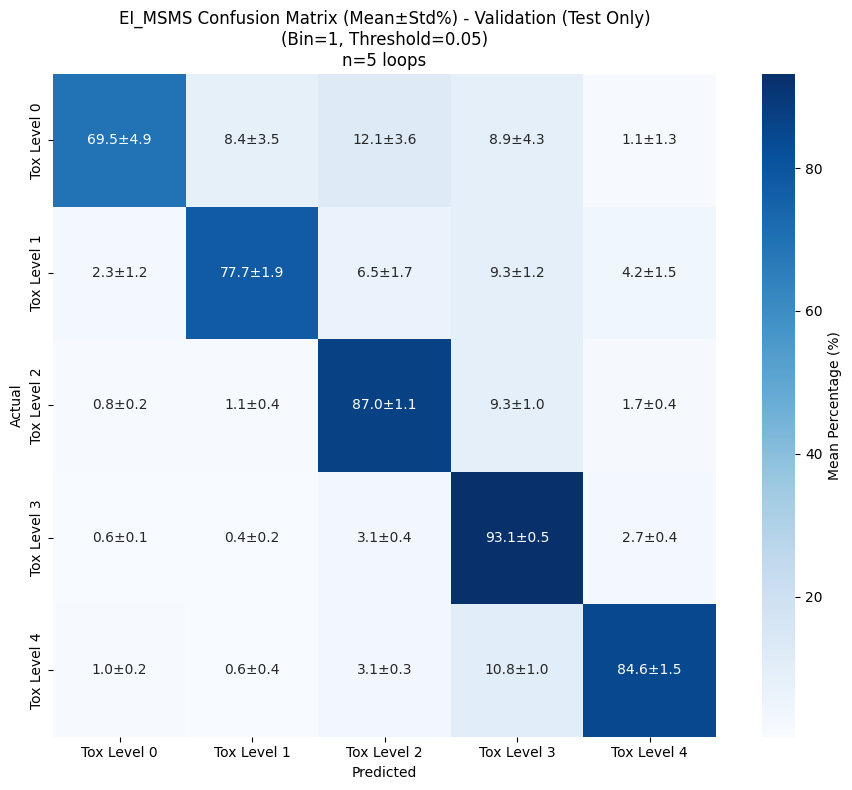

In [25]:
# Full Model (with synthetic data in training)
create_percentage_confusion_matrix_mean_std_EI_MSMS(
    folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
    folder_name='2_step_EI_MSMS_Loop',  # Match VAL_FINAL_DIR from training script
    bin_size=1,  # Use 1 (will become 1_0 in pattern matching)
    threshold_size=0.05, 
    use_super_test=False, 
    save_plots=False, 
    test_in=True,
    train_in=False, 
    num_loops=5
)


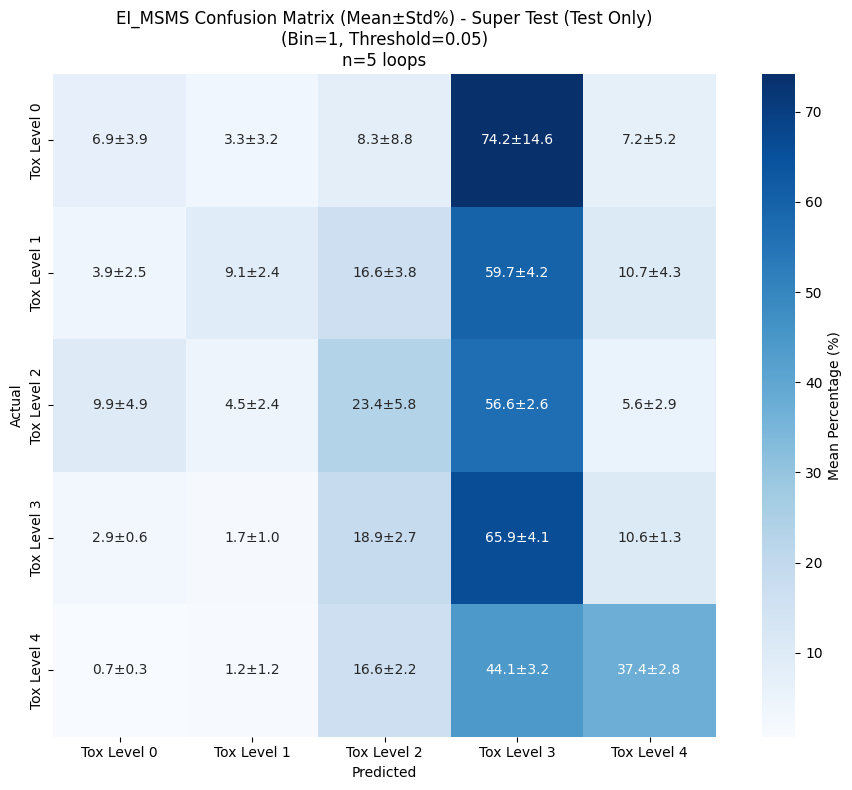

In [21]:
# Super Test Full Model
# Super Test - Full Model
create_percentage_confusion_matrix_mean_std_EI_MSMS(
    folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
    folder_name='2_step_EI_MSMS_loop_super_test', 
    bin_size=1,
    threshold_size=0.05, 
    use_super_test=True,  
    save_plots=False, 
    test_in=True,
    train_in=False, 
    num_loops=5
)


# Synthetic Ablation Model

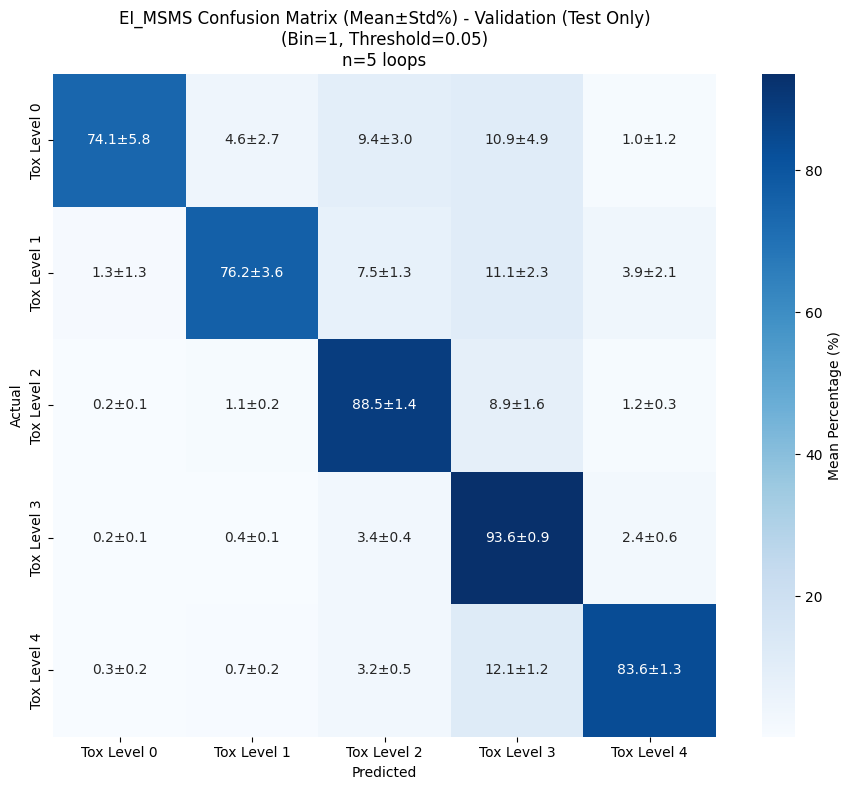

In [22]:
# Synthetic Ablation Model (without synthetic data in training)
create_percentage_confusion_matrix_mean_std_EI_MSMS(
    folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
    folder_name='2step_EI_MSMS_synth_abl_Loop',  # For synthetic ablation version
    bin_size=1,  # Use 1 
    threshold_size=0.05, 
    use_super_test=False, 
    save_plots=False, 
    test_in=True,
    train_in=False, 
    num_loops=5
)

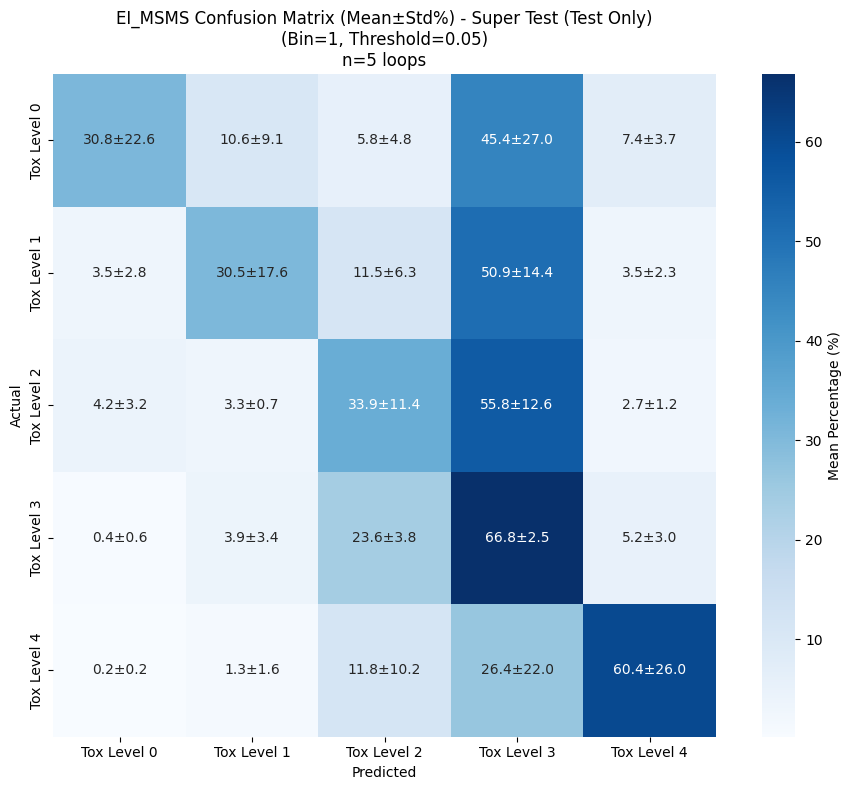

In [23]:
# Super Test - Synthetic Ablation
create_percentage_confusion_matrix_mean_std_EI_MSMS(
    folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
    folder_name='2step_EI_MSMS_synth_abl_loop_super_test',  # For synthetic ablation super test
    bin_size=1,
    threshold_size=0.05, 
    use_super_test=True,
    save_plots=False, 
    test_in=True,
    train_in=False, 
    num_loops=5
)